# Induced Seismicity Analysis

Analysis notebook for newly added induced seismicity datasets:

- Prefer registered catalogs: `<DATASET>-Standard` / `<DATASET>`
- Strict catalog loading only: no fallback to `InducedTripletBase`; unregistered datasets raise errors
- Supports both single-dataset analysis and multi-dataset batch comparison

## 1) Setup

In [25]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, peak_widths


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing both 'src' and 'data'.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.data.catalog as catalog
import src.catalogs as catalogs

pd.options.display.max_columns = 120
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Dataset Discovery

In [26]:
def discover_processed_triplet_datasets(data_root: Path) -> list[str]:
    datasets: list[str] = []
    for d in sorted(data_root.iterdir()):
        if not d.is_dir():
            continue
        name = d.name
        summary_path = d / 'processed' / f'{name}_summary.json'
        eq_path = d / 'processed' / f'{name}_eq_processed.csv'
        if summary_path.exists() and eq_path.exists():
            datasets.append(name)
    return datasets


triplet_datasets = discover_processed_triplet_datasets(PROJECT_ROOT / 'data')
registered_datasets = sorted([x for x in catalog.Catalog.list_available() if x.endswith('-Standard')])

print(f'Discovered processed triplet datasets ({len(triplet_datasets)}):')
print(triplet_datasets)
print(f"Registered '*-Standard' catalogs ({len(registered_datasets)}):")
print(registered_datasets)

Discovered processed triplet datasets (14):
['Basel', 'CB_HAB1a', 'CB_HAB1b', 'CB_HAB4', 'CCL', 'FORGE2022', 'Geysers', 'SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005', 'St1-2018', 'St1-2020']
Registered '*-Standard' catalogs (27):
['AZDX-Standard', 'Basel-Standard', 'CB_HAB1a-Standard', 'CB_HAB1b-Standard', 'CB_HAB4-Standard', 'CCL-Standard', 'ChinaArray-Standard', 'ChuanDian-Standard', 'CooperBasin-Standard', 'FORGE2022-Standard', 'Geysers-Standard', 'Hauksson-Standard', 'PNR-Standard', 'PNR_1z-Standard', 'PNR_2-Standard', 'QTMSaltonSea-Standard', 'QTMSanJacinto-Standard', 'SCEDC-Standard', 'SSFS-Standard', 'SSFS1993-Standard', 'SSFS2000-Standard', 'SSFS2003-Standard', 'SSFS2004-Standard', 'SSFS2005-Standard', 'St1-2018-Standard', 'St1-2020-Standard', 'White-Standard']


## 3) Flexible Catalog Loader

In [27]:
REGION_ALIASES = {
    'ssfs': 'SSFS',
    'cb': 'CooperBasin',
    'cooperbasin': 'CooperBasin',
    'cooper_basin': 'CooperBasin',
    'cooper-basin': 'CooperBasin',
    # 'geyers': 'Geysers',
}
REGION_MEMBERS = {
    'SSFS': ['SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005'],
    'CooperBasin': ['CB_HAB1a', 'CB_HAB1b', 'CB_HAB4'],
}


def normalize_dataset_name(dataset: str) -> str:
    token = str(dataset).strip()
    if not token:
        raise ValueError('dataset cannot be empty.')
    token_l = token.lower()
    return REGION_ALIASES[token_l] if token_l in REGION_ALIASES else token


def resolve_dataset_tokens(
    datasets: list[str],
    expand_region_members: bool = False,
) -> list[str]:
    resolved: list[str] = []
    for token in datasets:
        canonical = normalize_dataset_name(token)
        if expand_region_members and canonical in REGION_MEMBERS:
            resolved.extend(REGION_MEMBERS[canonical])
        else:
            resolved.append(canonical)

    deduped: list[str] = []
    seen: set[str] = set()
    for name in resolved:
        if name in seen:
            continue
        deduped.append(name)
        seen.add(name)
    return deduped


def load_catalog_flexible(dataset: str, catalog_cfg: dict[str, Any] | None = None):
    raw_dataset = str(dataset)
    dataset = normalize_dataset_name(raw_dataset)
    if dataset != raw_dataset:
        print(f'Resolved dataset alias: {raw_dataset!r} -> {dataset!r}')

    from src.utils.tpp_experiments import load_tpp_catalog

    ds, registry_name, _ = load_tpp_catalog(
        dataset,
        base_dir=PROJECT_ROOT / 'data' / dataset,
        catalog_cfg=catalog_cfg,
        candidates=[f'{dataset}-Standard', dataset],
    )
    print(f'Using registered catalog: {registry_name}')
    return ds


## 4) Series / Peak / Plot Helpers

In [28]:
def extract_injection_count_series(seq, metadata: dict[str, Any] | None = None) -> dict[str, Any]:
    if metadata is None:
        raise ValueError('metadata is required to build absolute timestamp axis.')
    if 'time_series' not in seq or 'time_series_times' not in seq:
        raise ValueError('Selected sequence has no time_series/time_series_times.')

    injection = seq.time_series.squeeze().detach().cpu().numpy()
    inj_time = seq.time_series_times.squeeze().detach().cpu().numpy()
    arrival_times = seq.arrival_times.detach().cpu().numpy()

    injection = np.asarray(injection).reshape(-1)
    inj_time = np.asarray(inj_time).reshape(-1)
    arrival_times = np.asarray(arrival_times).reshape(-1)

    if inj_time.shape[0] < 2:
        raise ValueError('time_series_times must contain at least 2 samples.')
    if injection.shape[0] != inj_time.shape[0]:
        raise ValueError(
            'time_series and time_series_times must have same length, got '
            f'{injection.shape[0]} vs {inj_time.shape[0]}'
        )

    bin_counts, _ = np.histogram(arrival_times, bins=inj_time)
    injection_mid = 0.5 * (injection[1:] + injection[:-1])
    inj_time_mid = 0.5 * (inj_time[1:] + inj_time[:-1])

    out: dict[str, Any] = {
        'injection': injection,
        'inj_time': inj_time,
        'injection_mid': injection_mid,
        'inj_time_mid': inj_time_mid,
        'arrival_times': arrival_times,
        'bin_counts': bin_counts,
        'inj_time_mid_ts': _build_absolute_time_axis(inj_time_mid, metadata),
    }

    return out


def _build_absolute_time_axis(
    rel_time: np.ndarray,
    metadata: dict[str, Any],
) -> pd.DatetimeIndex:
    required_md = ('start_ts', 'freq')
    missing_md = [k for k in required_md if k not in metadata]
    if missing_md:
        raise KeyError(f'Missing required metadata keys for timestamp axis: {missing_md}')

    start_ts = pd.Timestamp(metadata['start_ts'])
    if pd.isna(start_ts):
        raise ValueError(f"Invalid metadata['start_ts']: {metadata['start_ts']!r}")
    if start_ts.tz is not None:
        start_ts = start_ts.tz_convert('UTC').tz_localize(None)

    freq_td = pd.to_timedelta(metadata['freq'])
    if pd.isna(freq_td) or freq_td <= pd.Timedelta(0):
        raise ValueError(f"Invalid metadata['freq']: {metadata['freq']!r}")

    rel = np.asarray(rel_time, dtype=float).reshape(-1)
    if not np.isfinite(rel).all():
        bad = np.where(~np.isfinite(rel))[0][:10].tolist()
        raise ValueError(f'Found non-finite relative times at rows {bad}.')

    delta = pd.to_timedelta(rel * freq_td.total_seconds(), unit='s')
    return pd.DatetimeIndex(start_ts + delta)


def _resolve_plot_x(
    series: dict[str, Any],
    metadata: dict[str, Any] | None = None,
) -> tuple[pd.DatetimeIndex, str, bool]:
    if 'inj_time_mid_ts' in series:
        x_ts = pd.DatetimeIndex(series['inj_time_mid_ts'])
        return x_ts, 'Time (timestamp)', True

    if metadata is None:
        raise ValueError("Missing 'inj_time_mid_ts' and metadata is None.")

    if 'inj_time_mid' not in series:
        raise KeyError("Missing 'inj_time_mid' in series.")

    x_ts = _build_absolute_time_axis(series['inj_time_mid'], metadata)
    return x_ts, 'Time (timestamp)', True


def _apply_timestamp_axis(ax) -> None:
    x_min, x_max = ax.get_xlim()
    span_days = max(float(x_max - x_min), 1e-9)
    locator = mticker.MaxNLocator(nbins=7, min_n_ticks=4, prune='both')
    if span_days >= 365:
        fmt = '%Y'
    elif span_days >= 180:
        fmt = '%Y-%m'
    elif span_days >= 2:
        fmt = '%m-%d'
    elif span_days >= 0.25:
        fmt = '%m-%d\n%H:%M'
    else:
        fmt = '%H:%M'
    formatter = mdates.DateFormatter(fmt)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelrotation=0)


PLOT_FIGSIZE = (11.5, 6.4)
PLOT_DPI = 300
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 11
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 10


def _style_timeseries_axis(ax, *, ylabel: str, color: str) -> None:
    ax.set_ylabel(ylabel, color=color, fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(True, which='major', color='0.86', linewidth=0.8, alpha=0.8)
    ax.margins(x=0)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)


def _set_y_limits(ax, values, *, zero_floor: bool = True, headroom: float = 0.12) -> None:
    arr = np.asarray(values, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return
    y_min = float(np.nanmin(arr))
    y_max = float(np.nanmax(arr))
    if zero_floor and y_min >= 0:
        y_min = 0.0
    span = y_max - y_min
    pad = max(span * headroom, 1e-6)
    if span <= 0:
        pad = max(abs(y_max) * headroom, 0.05)
    ax.set_ylim(y_min, y_max + pad)


def _finish_timeseries_figure(fig, axes, *, title: str, is_timestamp: bool, xlabel: str) -> None:
    axes = list(axes)
    axes[-1].set_xlabel(xlabel, fontsize=LABEL_FONTSIZE)
    if is_timestamp:
        _apply_timestamp_axis(axes[-1])
    for ax in axes[:-1]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
    axes[-1].tick_params(axis='x', which='both', labelbottom=True)
    for ax in axes:
        ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    fig.suptitle(title, fontsize=TITLE_FONTSIZE, fontweight='normal', y=0.965)
    fig.align_ylabels(axes)
    fig.subplots_adjust(left=0.075, right=0.985, top=0.895, bottom=0.105, hspace=0.12)



def detect_peaks(
    injection_mid: np.ndarray,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
) -> dict[str, np.ndarray]:
    peaks_idx, props = find_peaks(
        injection_mid,
        height=peak_height,
        distance=peak_min_distance,
    )

    if 'peak_heights' not in props:
        raise KeyError("find_peaks result missing 'peak_heights'.")

    widths, width_heights, left_bases_float, right_bases_float = peak_widths(
        x=injection_mid,
        peaks=peaks_idx,
        rel_height=1,
    )

    left_bases = np.round(left_bases_float).astype(int)
    right_bases = np.round(right_bases_float).astype(int)

    return {
        'peaks_idx': peaks_idx,
        'peak_heights': np.asarray(props['peak_heights']),
        'widths': widths,
        'width_heights': width_heights,
        'left_bases': left_bases,
        'right_bases': right_bases,
    }


def _plot_event_counts(
    ax,
    x,
    bin_counts: np.ndarray,
    *,
    is_timestamp: bool,
    aggregate_daily: bool = False,
):
    counts = np.asarray(bin_counts).reshape(-1)
    if aggregate_daily and is_timestamp:
        daily_counts = pd.Series(counts, index=pd.DatetimeIndex(x)).resample('1D').sum()
        ax.bar(
            daily_counts.index,
            daily_counts.to_numpy(),
            width=0.9,
            align='edge',
            color='tab:orange',
            alpha=0.7,
            edgecolor='tab:orange',
            linewidth=0.2,
            label='Event Count (daily sum)',
        )
        ylabel = 'Daily Event Count'
        values = daily_counts.to_numpy()
    else:
        x_arr = pd.DatetimeIndex(x) if is_timestamp else np.asarray(x)
        nz = counts > 0
        ax.vlines(
            x_arr[nz],
            0,
            counts[nz],
            color='tab:orange',
            alpha=0.75,
            linewidth=0.9,
            label='Event Count',
        )
        values = counts[nz]
        ylabel = 'Event Count'

    _style_timeseries_axis(ax, ylabel=ylabel, color='tab:orange')
    _set_y_limits(ax, values, zero_floor=True)
    ax.legend(loc='upper right', frameon=True, framealpha=0.92, fontsize=LEGEND_FONTSIZE)


def plot_global_overlay(
    dataset: str,
    series: dict[str, Any],
    metadata: dict[str, Any] | None = None,
    save_path: Path | None = None,
    show: bool = True,
    dpi: int = PLOT_DPI,
) -> Path | None:
    x, x_label, is_timestamp = _resolve_plot_x(series, metadata=metadata)
    injection_mid = series['injection_mid']
    bin_counts = series['bin_counts']

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=PLOT_FIGSIZE,
        sharex=True,
        gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.08},
    )
    ax1.plot(x, injection_mid, color='tab:blue', linewidth=1.2, label='Injection Rate')
    _style_timeseries_axis(ax1, ylabel='Injection Rate (m³/min)', color='tab:blue')
    _set_y_limits(ax1, injection_mid, zero_floor=True)
    ax1.legend(loc='upper right', frameon=True, framealpha=0.92, fontsize=LEGEND_FONTSIZE)

    _plot_event_counts(ax2, x, bin_counts, is_timestamp=is_timestamp, aggregate_daily=True)

    _finish_timeseries_figure(
        fig,
        (ax1, ax2),
        title=f'{dataset}: Injection Rate and Event Count',
        is_timestamp=is_timestamp,
        xlabel=x_label,
    )

    saved: Path | None = None
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi)
        saved = save_path

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved



def _resolve_peak_rank(
    peaks_idx: np.ndarray,
    peak_rank: int,
    *,
    dataset: str | None = None,
) -> int | None:
    n_peaks = int(len(peaks_idx))
    if n_peaks == 0:
        label = dataset or 'plot_peak_window'
        print(f'{label}: no peaks found with current thresholds.')
        return None

    requested_peak_rank = int(peak_rank)
    resolved_peak_rank = min(max(requested_peak_rank, 0), n_peaks - 1)
    if resolved_peak_rank != requested_peak_rank:
        label = dataset or 'plot_peak_window'
        print(
            f'{label}: requested peak_rank={requested_peak_rank}, but only found {n_peaks} peak(s); '
            f'using peak_rank={resolved_peak_rank}.'
        )
    return resolved_peak_rank


def plot_peak_window(
    dataset: str,
    series: dict[str, Any],
    peaks: dict[str, np.ndarray],
    peak_rank: int = 0,
    offset: int = 50,
    metadata: dict[str, Any] | None = None,
    save_path: Path | None = None,
    show: bool = True,
    dpi: int = PLOT_DPI,
) -> Path | None:
    peaks_idx = peaks['peaks_idx']
    left = peaks['left_bases']
    right = peaks['right_bases']

    resolved_peak_rank = _resolve_peak_rank(peaks_idx, peak_rank, dataset=dataset)
    if resolved_peak_rank is None:
        return None

    x, x_label, is_timestamp = _resolve_plot_x(series, metadata=metadata)
    injection_mid = series['injection_mid']
    bin_counts = series['bin_counts']

    lb = int(left[resolved_peak_rank])
    rb = int(right[resolved_peak_rank])
    start = max(0, lb - offset)
    end = min(len(injection_mid), rb + offset)

    x_window = x[start:end]
    bin_counts_window = bin_counts[start:end]

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=PLOT_FIGSIZE,
        sharex=True,
        gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.08},
    )
    injection_window = injection_mid[start:end]
    ax1.plot(x_window, injection_window, color='tab:blue', label='Injection Rate', linewidth=1.2)
    _style_timeseries_axis(ax1, ylabel='Injection Rate (m³/min)', color='tab:blue')
    _set_y_limits(ax1, injection_window, zero_floor=True)

    ax1.axvline(x[lb], color='tab:green', linestyle='--', linewidth=1.1, label='left_base')
    ax1.axvline(x[rb], color='tab:red', linestyle='--', linewidth=1.1, label='right_base')

    peak_idx = int(peaks_idx[resolved_peak_rank])
    ax1.plot(x[peak_idx], injection_mid[peak_idx], 'o', color='black', markersize=4.5, label='peak')

    _plot_event_counts(ax2, x_window, bin_counts_window, is_timestamp=is_timestamp)
    ax2.axvline(x[lb], color='tab:green', linestyle='--', linewidth=1.1, alpha=0.8)
    ax2.axvline(x[rb], color='tab:red', linestyle='--', linewidth=1.1, alpha=0.8)

    ax1.legend(loc='upper right', frameon=True, framealpha=0.92, fontsize=LEGEND_FONTSIZE)

    title_rank = f'{resolved_peak_rank}'
    if resolved_peak_rank != int(peak_rank):
        title_rank = f'{resolved_peak_rank} (requested {int(peak_rank)})'
    _finish_timeseries_figure(
        fig,
        (ax1, ax2),
        title=f'{dataset}: peak#{title_rank} window [{start}, {end})',
        is_timestamp=is_timestamp,
        xlabel=x_label,
    )

    saved: Path | None = None
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi)
        saved = save_path

    if show:
        plt.show()
    else:
        plt.close(fig)

    return saved



def summarize_catalog(dataset: str, catalog_ds, series: dict[str, np.ndarray], peaks: dict[str, np.ndarray]) -> dict[str, Any]:
    seq = catalog_ds.full_sequence
    md = catalog_ds.metadata
    required_md = ('name', 'freq', 'mag_completeness')
    missing_md = [k for k in required_md if k not in md]
    if missing_md:
        raise KeyError(f'Missing required metadata keys in catalog: {missing_md}')

    injection_sum = float(series['injection_mid'].sum())
    count_sum = float(series['bin_counts'].sum())
    ratio = count_sum / injection_sum if injection_sum > 0 else np.nan

    return {
        'dataset': dataset,
        'catalog_name': md['name'],
        'freq': md['freq'],
        'n_events': int(len(seq)),
        'duration': float(seq.t_end - seq.t_start),
        'injection_sum': injection_sum,
        'count_sum': count_sum,
        'count_to_injection_ratio': float(ratio),
        'n_peaks': int(len(peaks['peaks_idx'])),
        'mag_completeness': float(md['mag_completeness']),
    }


def compare_datasets(
    datasets: list[str],
    catalog_cfg: dict[str, Any] | None = None,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
) -> tuple[pd.DataFrame, dict[str, dict[str, Any]]]:
    rows: list[dict[str, Any]] = []
    cache: dict[str, dict[str, Any]] = {}

    for ds_name in datasets:
        cat_ds = load_catalog_flexible(ds_name, catalog_cfg)
        series = extract_injection_count_series(cat_ds.full_sequence, metadata=cat_ds.metadata)
        peaks = detect_peaks(
            injection_mid=series['injection_mid'],
            peak_height=peak_height,
            peak_min_distance=peak_min_distance,
        )
        rows.append(summarize_catalog(ds_name, cat_ds, series, peaks))
        cache[ds_name] = {'catalog': cat_ds, 'series': series, 'peaks': peaks}

    df = pd.DataFrame(rows)
    df = df.sort_values('n_events', ascending=False).reset_index(drop=True)
    return df, cache

def export_triplet_plots(
    datasets: list[str],
    catalog_cfg: dict[str, Any] | None = None,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
    peak_rank: int = 0,
    offset: int = 60,
    output_subdir: str = 'analysis_plots',
    dpi: int = PLOT_DPI,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for ds_name in datasets:
        resolved = normalize_dataset_name(ds_name)
        cat_ds = load_catalog_flexible(resolved, catalog_cfg)
        series = extract_injection_count_series(cat_ds.full_sequence, metadata=cat_ds.metadata)
        peaks = detect_peaks(
            injection_mid=series['injection_mid'],
            peak_height=peak_height,
            peak_min_distance=peak_min_distance,
        )

        out_dir = PROJECT_ROOT / 'data' / resolved / output_subdir
        out_dir.mkdir(parents=True, exist_ok=True)

        global_path = out_dir / f'{resolved}_global_overlay.png'
        resolved_peak_rank = _resolve_peak_rank(peaks['peaks_idx'], peak_rank, dataset=resolved)
        peak_suffix = f'peak_rank{resolved_peak_rank}' if resolved_peak_rank is not None else 'peak_rank_none'
        peak_path = out_dir / f'{resolved}_{peak_suffix}_offset{offset}.png'
        mag_dist_path = out_dir / f'{resolved}_magnitude_distribution.png'

        saved_global = plot_global_overlay(
            resolved,
            series,
            metadata=cat_ds.metadata,
            save_path=global_path,
            show=False,
            dpi=dpi,
        )
        saved_peak = None
        if resolved_peak_rank is not None:
            saved_peak = plot_peak_window(
                resolved,
                series,
                peaks,
                peak_rank=resolved_peak_rank,
                offset=offset,
                metadata=cat_ds.metadata,
                save_path=peak_path,
                show=False,
                dpi=dpi,
            )

        m = cat_ds.full_sequence.mag
        mags = m.detach().cpu().numpy().reshape(-1) if hasattr(m, 'detach') else np.asarray(m).reshape(-1)
        mags = mags[np.isfinite(mags)]

        saved_mag_dist = None
        if mags.size > 0:
            bin_width = 0.1
            bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + bin_width, bin_width)
            if bins.size < 2:
                bins = np.array([mags.min() - 0.05, mags.max() + 0.05])

            fig, ax = plt.subplots(figsize=(7, 4))
            ax.hist(mags, bins=bins, color='tab:blue', edgecolor='black', alpha=0.8)
            ax.set_xlabel('Magnitude')
            ax.set_ylabel('Count')
            ax.set_title('Magnitude Distribution for ' + resolved)
            ax.grid(alpha=0.3)
            fig.tight_layout()
            fig.savefig(mag_dist_path, dpi=dpi, bbox_inches='tight')
            plt.close(fig)
            saved_mag_dist = mag_dist_path

        rows.append({
            'dataset': resolved,
            'n_peaks': int(len(peaks['peaks_idx'])),
            'requested_peak_rank': int(peak_rank),
            'effective_peak_rank': int(resolved_peak_rank) if resolved_peak_rank is not None else None,
            'global_plot': str(saved_global.relative_to(PROJECT_ROOT)) if saved_global is not None else None,
            'peak_plot': str(saved_peak.relative_to(PROJECT_ROOT)) if saved_peak is not None else None,
            'magnitude_distribution_plot': str(saved_mag_dist.relative_to(PROJECT_ROOT)) if saved_mag_dist is not None else None,
            'output_dir': str(out_dir.relative_to(PROJECT_ROOT)),
        })

    return pd.DataFrame(rows)


## 5) Single Dataset Analysis

In [29]:
registered_datasets

['AZDX-Standard',
 'Basel-Standard',
 'CB_HAB1a-Standard',
 'CB_HAB1b-Standard',
 'CB_HAB4-Standard',
 'CCL-Standard',
 'ChinaArray-Standard',
 'ChuanDian-Standard',
 'CooperBasin-Standard',
 'FORGE2022-Standard',
 'Geysers-Standard',
 'Hauksson-Standard',
 'PNR-Standard',
 'PNR_1z-Standard',
 'PNR_2-Standard',
 'QTMSaltonSea-Standard',
 'QTMSanJacinto-Standard',
 'SCEDC-Standard',
 'SSFS-Standard',
 'SSFS1993-Standard',
 'SSFS2000-Standard',
 'SSFS2003-Standard',
 'SSFS2004-Standard',
 'SSFS2005-Standard',
 'St1-2018-Standard',
 'St1-2020-Standard',
 'White-Standard']

In [30]:
DATASET ='CCL' # 'cb'  
CATALOG_CFG = {
    # 'mag_completeness': 2.2,
    'normalize': False,
    # 'end_ts': "2018-8-21T23:59:59",
    'resample_freq_min': 10,
}
# CATALOG_CFG = None
PEAK_HEIGHT = 0.5
PEAK_MIN_DISTANCE = 60

RESOLVED_DATASET = normalize_dataset_name(DATASET)
print(f'Selected dataset: {DATASET!r} -> {RESOLVED_DATASET!r}')

catalog_ds = load_catalog_flexible(DATASET, CATALOG_CFG)
series = extract_injection_count_series(catalog_ds.full_sequence, metadata=catalog_ds.metadata)
peaks = detect_peaks(
    injection_mid=series['injection_mid'],
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
)

single_summary = summarize_catalog(
    dataset=RESOLVED_DATASET,
    catalog_ds=catalog_ds,
    series=series,
    peaks=peaks,
)
single_summary

Selected dataset: 'CCL' -> 'CCL'
Using registered catalog: CCL-Standard


{'dataset': 'CCL',
 'catalog_name': 'CCL',
 'freq': '1h',
 'n_events': 14008,
 'duration': 5345.64990234375,
 'injection_sum': 16427.642578125,
 'count_sum': 14008.0,
 'count_to_injection_ratio': 0.8527090806475794,
 'n_peaks': 70,
 'mag_completeness': 0.5}

In [31]:
max(catalog_ds.full_sequence.time_series)

tensor([70.2990])

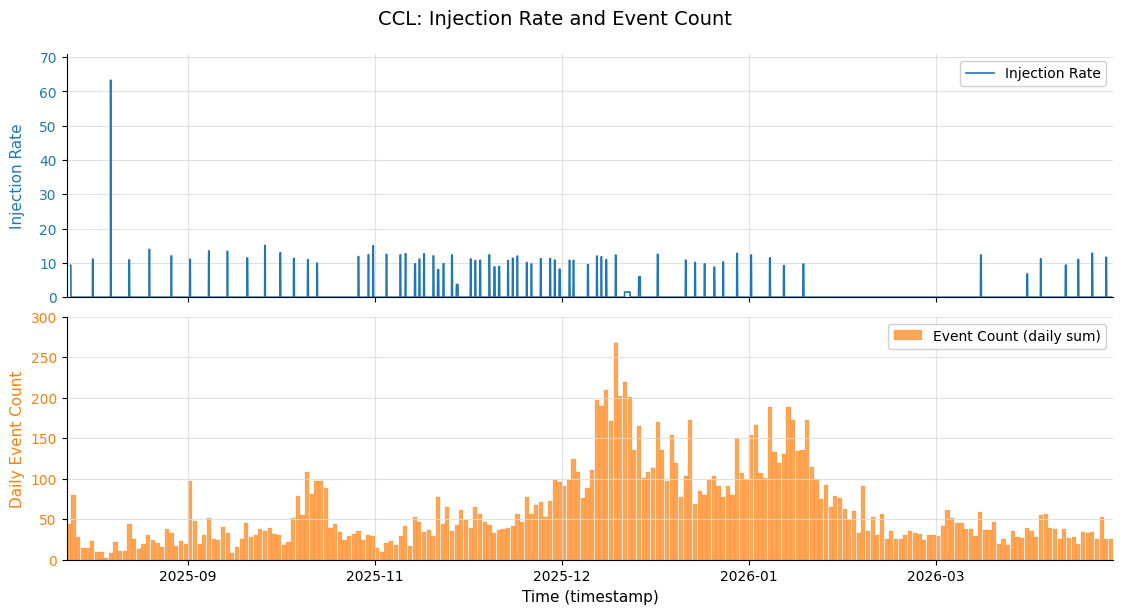

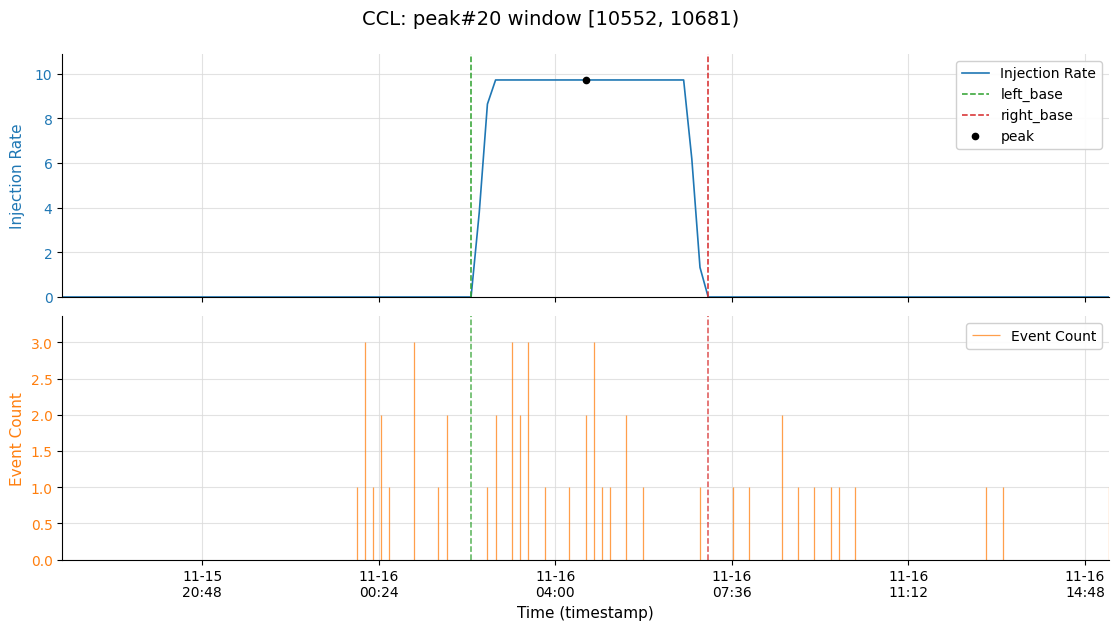

In [32]:
plot_global_overlay(RESOLVED_DATASET, series, metadata=catalog_ds.metadata)
plot_peak_window(RESOLVED_DATASET, series, peaks, peak_rank=20, offset=50, metadata=catalog_ds.metadata)


In [33]:
DATASETS_TO_COMPARE = ['ssfs']
EXPAND_REGION_MEMBERS = True
CATALOG_CFG = {
    'mag_completeness': -10,
    'normalize': False,
}
resolved_datasets = resolve_dataset_tokens(
    DATASETS_TO_COMPARE,
    expand_region_members=EXPAND_REGION_MEMBERS,
)
catalog_ds_dict = {}
for i,ds_name in enumerate(resolved_datasets):
    catalog_ds = load_catalog_flexible(ds_name, CATALOG_CFG)
    catalog_ds_dict[ds_name] = catalog_ds

Using registered catalog: SSFS1993-Standard
Using registered catalog: SSFS2000-Standard
Using registered catalog: SSFS2003-Standard
Using registered catalog: SSFS2004-Standard
Using registered catalog: SSFS2005-Standard


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


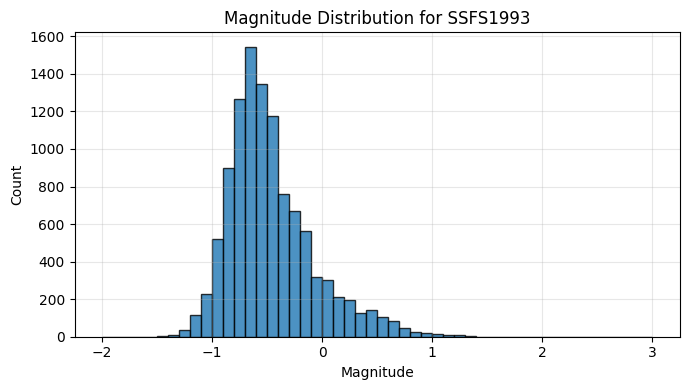

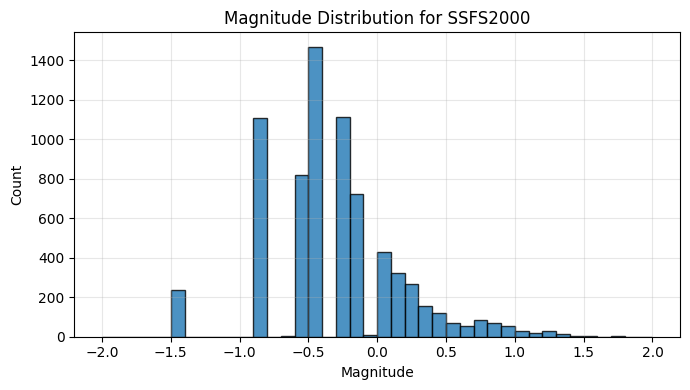

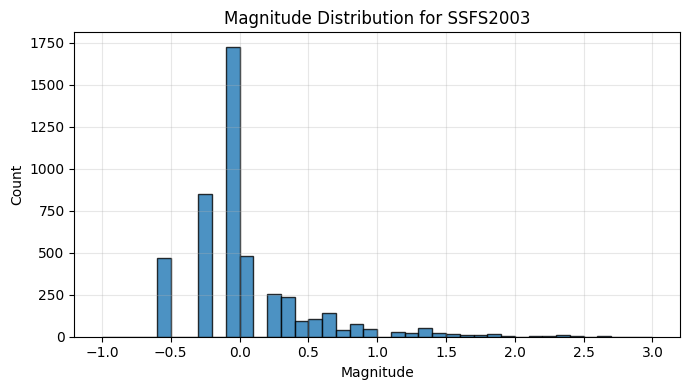

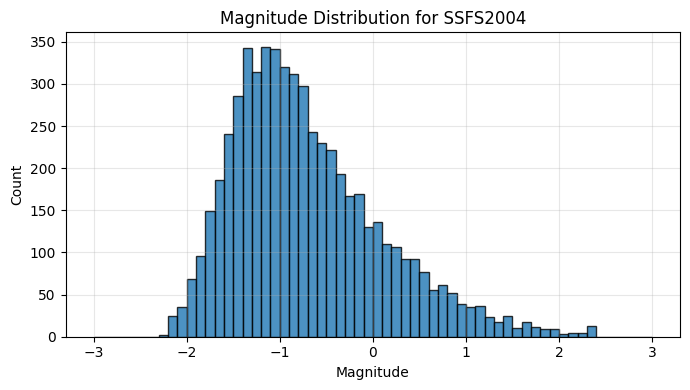

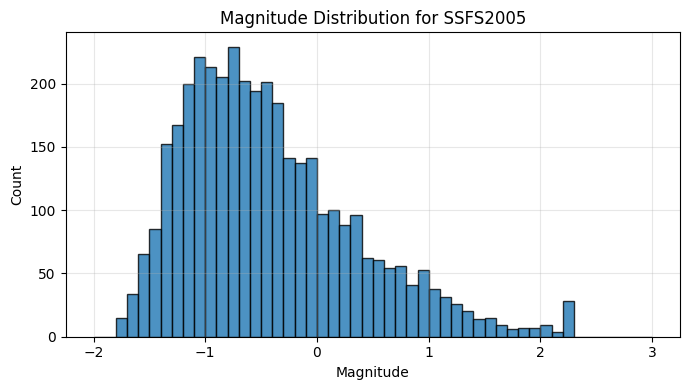

In [34]:
for ds_name in resolved_datasets:
    m = catalog_ds_dict[ds_name].full_sequence.mag
    mags = m.detach().cpu().numpy().reshape(-1) if hasattr(m, 'detach') else np.asarray(m).reshape(-1)
    mags = mags[np.isfinite(mags)]

    bin_width = 0.1
    bins = np.arange(np.floor(mags.min()), np.ceil(mags.max()) + bin_width, bin_width)

    plt.figure(figsize=(7, 4))
    plt.hist(mags, bins=bins, color='tab:blue', edgecolor='black', alpha=0.8)
    plt.xlabel('Magnitude')
    plt.ylabel('Count')
    plt.title('Magnitude Distribution for ' + ds_name)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6) Batch Comparison

In [35]:
DATASETS_TO_COMPARE = [
    'FORGE2022',
    'St1-2020',
    'ssfs',
    'cb',
    'Basel',
]

EXPAND_REGION_MEMBERS = True  # True 时会把 ssfs/cb 展开成具体子数据集

resolved_datasets = resolve_dataset_tokens(
    DATASETS_TO_COMPARE,
    expand_region_members=EXPAND_REGION_MEMBERS,
)
print('Resolved datasets:', resolved_datasets)

compare_df, compare_cache = compare_datasets(
    datasets=resolved_datasets,
    catalog_cfg=CATALOG_CFG,
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
)

compare_df

Resolved datasets: ['FORGE2022', 'St1-2020', 'SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005', 'CB_HAB1a', 'CB_HAB1b', 'CB_HAB4', 'Basel']
Using registered catalog: FORGE2022-Standard
Using registered catalog: St1-2020-Standard
Using registered catalog: SSFS1993-Standard
Using registered catalog: SSFS2000-Standard
Using registered catalog: SSFS2003-Standard
Using registered catalog: SSFS2004-Standard
Using registered catalog: SSFS2005-Standard
Using registered catalog: CB_HAB1a-Standard
Using registered catalog: CB_HAB1b-Standard
Using registered catalog: CB_HAB4-Standard
Using registered catalog: Basel-Standard


,dataset,catalog_name,freq,n_events,duration,injection_sum,count_sum,count_to_injection_ratio,n_peaks,mag_completeness
0,FORGE2022,FORGE2022,1h,34908,188.550003,206.421494,34908.0,169.110297,4,-10.0
1,CB_HAB1a,CB_HAB1a,1h,23285,1121.966553,6195.636230,23285.0,3.758290,28,-10.0
2,CB_HAB4,CB_HAB4,1h,20735,571.133362,10333.884766,20735.0,2.006506,53,-10.0
3,SSFS1993,SSFS1993,1h,10743,515.116638,2267.233887,10742.0,4.737932,28,-10.0
4,CB_HAB1b,CB_HAB1b,1h,8282,487.000000,9021.723633,8282.0,0.918006,122,-10.0
5,SSFS2000,SSFS2000,1h,7215,252.400009,1505.072998,7214.0,4.793123,22,-10.0
6,St1-2020,St1-2020,1h,6227,3217.473145,2389.170166,6227.0,2.606344,14,-10.0
7,SSFS2004,SSFS2004,1h,5753,405.516693,2646.210938,5752.0,2.173674,14,-10.0
8,SSFS2003,SSFS2003,1h,4728,1115.116699,4900.228516,4726.0,0.964445,25,-10.0
9,Basel,Basel,1h,3715,102414.351562,3293.511230,3715.0,1.127976,3,-10.0


## 7) Batch Export Plots for All Triple Datasets

In [36]:
TRIPLET_PLOT_OUTPUT_SUBDIR = 'analysis_plots'
CATALOG_CFG = {
    'mag_completeness': -10,
    'normalize': False,
}
triplet_plot_df = export_triplet_plots(
    datasets=triplet_datasets,
    catalog_cfg=CATALOG_CFG,
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
    peak_rank=0,
    offset=60,
    output_subdir=TRIPLET_PLOT_OUTPUT_SUBDIR,
)
triplet_plot_df


/root/autodl-tmp/em_eqf/src/data/sequence.py:345: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


Using registered catalog: Basel-Standard
Using registered catalog: CB_HAB1a-Standard
Using registered catalog: CB_HAB1b-Standard
Using registered catalog: CB_HAB4-Standard
Using registered catalog: CCL-Standard
Using registered catalog: FORGE2022-Standard
Using registered catalog: Geysers-Standard
Using registered catalog: SSFS1993-Standard
Using registered catalog: SSFS2000-Standard
Using registered catalog: SSFS2003-Standard
Using registered catalog: SSFS2004-Standard
Using registered catalog: SSFS2005-Standard
Using registered catalog: St1-2018-Standard
Using registered catalog: St1-2020-Standard


,dataset,n_peaks,requested_peak_rank,effective_peak_rank,global_plot,peak_plot,magnitude_distribution_plot,output_dir
0,Basel,3,0,0,data/Basel/analysis_plots/Basel_global_overlay...,data/Basel/analysis_plots/Basel_peak_rank0_off...,data/Basel/analysis_plots/Basel_magnitude_dist...,data/Basel/analysis_plots
1,CB_HAB1a,28,0,0,data/CB_HAB1a/analysis_plots/CB_HAB1a_global_o...,data/CB_HAB1a/analysis_plots/CB_HAB1a_peak_ran...,data/CB_HAB1a/analysis_plots/CB_HAB1a_magnitud...,data/CB_HAB1a/analysis_plots
2,CB_HAB1b,122,0,0,data/CB_HAB1b/analysis_plots/CB_HAB1b_global_o...,data/CB_HAB1b/analysis_plots/CB_HAB1b_peak_ran...,data/CB_HAB1b/analysis_plots/CB_HAB1b_magnitud...,data/CB_HAB1b/analysis_plots
3,CB_HAB4,53,0,0,data/CB_HAB4/analysis_plots/CB_HAB4_global_ove...,data/CB_HAB4/analysis_plots/CB_HAB4_peak_rank0...,data/CB_HAB4/analysis_plots/CB_HAB4_magnitude_...,data/CB_HAB4/analysis_plots
4,CCL,1,0,0,data/CCL/analysis_plots/CCL_global_overlay.png,data/CCL/analysis_plots/CCL_peak_rank0_offset6...,data/CCL/analysis_plots/CCL_magnitude_distribu...,data/CCL/analysis_plots
5,FORGE2022,4,0,0,data/FORGE2022/analysis_plots/FORGE2022_global...,data/FORGE2022/analysis_plots/FORGE2022_peak_r...,data/FORGE2022/analysis_plots/FORGE2022_magnit...,data/FORGE2022/analysis_plots
6,Geysers,17,0,0,data/Geysers/analysis_plots/Geysers_global_ove...,data/Geysers/analysis_plots/Geysers_peak_rank0...,data/Geysers/analysis_plots/Geysers_magnitude_...,data/Geysers/analysis_plots
7,SSFS1993,28,0,0,data/SSFS1993/analysis_plots/SSFS1993_global_o...,data/SSFS1993/analysis_plots/SSFS1993_peak_ran...,data/SSFS1993/analysis_plots/SSFS1993_magnitud...,data/SSFS1993/analysis_plots
8,SSFS2000,22,0,0,data/SSFS2000/analysis_plots/SSFS2000_global_o...,data/SSFS2000/analysis_plots/SSFS2000_peak_ran...,data/SSFS2000/analysis_plots/SSFS2000_magnitud...,data/SSFS2000/analysis_plots
9,SSFS2003,25,0,0,data/SSFS2003/analysis_plots/SSFS2003_global_o...,data/SSFS2003/analysis_plots/SSFS2003_peak_ran...,data/SSFS2003/analysis_plots/SSFS2003_magnitud...,data/SSFS2003/analysis_plots
